
# Constrained Branin–Hoo example with two nonlinear constraints

This notebook builds a **constrained** version of the classical Branin–Hoo test problem.  
The goal is to make the geometry clear:

$
\min_{\mathbf{x}\in\mathbb{R}^2} f(x_1,x_2)
$

subject to two nonlinear inequality constraints

$
c_1(x_1,x_2)\ge 0,
\qquad
c_2(x_1,x_2)\ge 0,
$

together with the standard Branin box

$
-5 \le x_1 \le 10, \qquad 0 \le x_2 \le 15.
$

We will:

1. define the objective and the two nonlinear constraints,
2. visualize the feasible set,
3. solve the constrained problem with SciPy,
4. compare a few local runs from different starting points.


In [24]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Optional: make plots look cleaner
plt.rcParams.update({
    "figure.figsize": (8, 6),
    "axes.grid": True,
    "font.size": 12,
})



## 1. Objective: the Branin–Hoo function

We use the standard Branin function

$
f(x_1,x_2)
=
\left(x_2-\frac{5.1}{4\pi^2}x_1^2+\frac{5}{\pi}x_1-6\right)^2
+10\left(1-\frac{1}{8\pi}\right)\cos(x_1)+10.
$

It has three well-known global minima in the unconstrained case, but the constraints below will cut away parts of the domain and change the answer.


In [2]:

def branin(x):
    x1, x2 = x
    a = 1.0
    b = 5.1 / (4 * np.pi**2)
    c = 5 / np.pi
    r = 6.0
    s = 10.0
    t = 1 / (8 * np.pi)
    return a * (x2 - b * x1**2 + c * x1 - r)**2 + s * (1 - t) * np.cos(x1) + s

# Standard Branin box
bounds = [(-5.0, 10.0), (0.0, 15.0)]



## 2. Two nonlinear constraints

We now impose two nonlinear inequalities.

### Constraint 1: a curved elliptical region
$
c_1(x_1,x_2)=
1-\frac{(x_1-2.5)^2}{30}-\frac{(x_2-7.5)^2}{20}.
$

The feasible side is the **inside** of this ellipse:
$
c_1(x_1,x_2)\ge 0.
$

### Constraint 2: a sinusoidally warped cap
$
c_2(x_1,x_2)=
0.4 + 0.35\sin(0.9x_1) - 0.03(x_2-8)^2.
$

Again, the feasible side is
$
c_2(x_1,x_2)\ge 0.
$

The intersection of these two sets, together with the box bounds, is our admissible design region.


In [3]:

def c1(x):
    x1, x2 = x
    return 1.0 - ((x1 - 2.5)**2) / 30.0 - ((x2 - 7.5)**2) / 20.0

def c2(x):
    x1, x2 = x
    return 0.4 + 0.35 * np.sin(0.9 * x1) - 0.03 * (x2 - 8.0)**2

constraints = [
    {"type": "ineq", "fun": c1},
    {"type": "ineq", "fun": c2},
]



## 3. Visualize the objective and the feasible region


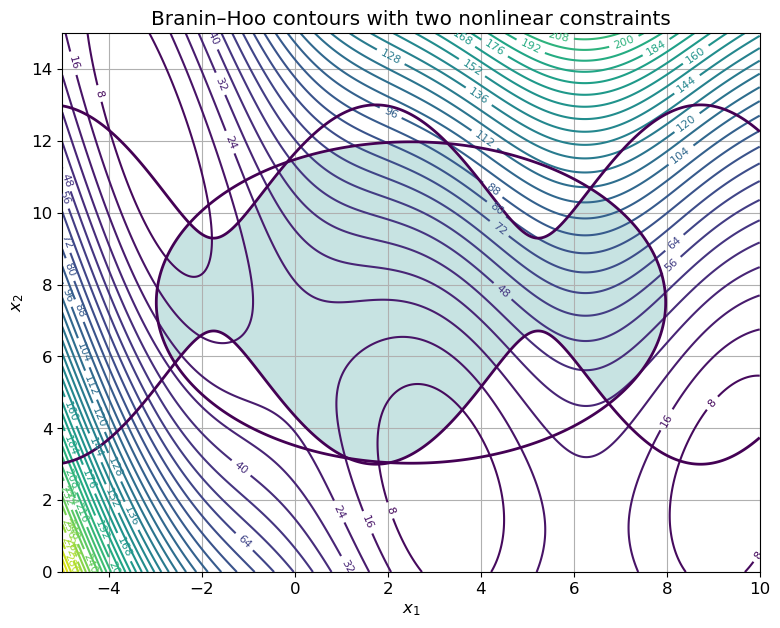

In [4]:

# Build a grid over the Branin box
x1 = np.linspace(bounds[0][0], bounds[0][1], 500)
x2 = np.linspace(bounds[1][0], bounds[1][1], 500)
X1, X2 = np.meshgrid(x1, x2)

F = branin((X1, X2))
C1 = c1((X1, X2))
C2 = c2((X1, X2))
feasible = (C1 >= 0) & (C2 >= 0)

plt.figure(figsize=(9, 7))
contours = plt.contour(X1, X2, F, levels=40)
plt.clabel(contours, inline=True, fontsize=8)

# Plot constraint boundaries
plt.contour(X1, X2, C1, levels=[0], linewidths=2)
plt.contour(X1, X2, C2, levels=[0], linewidths=2)

# Shade feasible region
plt.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], alpha=0.25)

plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Branin–Hoo contours with two nonlinear constraints")
plt.show()



In the plot above:

- the contour lines are the Branin objective,
- each thick curve is a constraint boundary \(c_i(\mathbf{x})=0\),
- the shaded region is where **both** constraints are satisfied.

So the optimizer must move only inside that shaded region.



## 4. Solve the constrained problem from one starting point

We first solve from a single initial guess.  
Because the Branin function is nonconvex, this is only a **local** solve.


In [28]:

x0 = np.array([0.0, 10.0])

methods = ["COBYLA", "COBYQA"]#, "SLSQP"]
results_single = {}

for method in methods:
    results_single[method] = minimize(
        branin,
        x0=x0,
        method=method,
        bounds=bounds,
        constraints=constraints,
    )

for method, res in results_single.items():
    print(f"Method: {method}")
    print(f"  success      = {res.success}")
    print(f"  x*           = {res.x}")
    print(f"  f(x*)        = {res.fun:.6f}")
    print(f"  c1(x*)       = {c1(res.x):.6e}")
    print(f"  c2(x*)       = {c2(res.x):.6e}")
    print(f"  message      = {res.message}")
    print()


Method: COBYLA
  success      = True
  x*           = [-2.35674661  9.56752869]
  f(x*)        = 4.018107
  c1(x*)       = -6.779439e-10
  c2(x*)       = 2.795247e-02
  message      = Return from COBYLA because the trust region radius reaches its lower bound.

Method: COBYQA
  success      = True
  x*           = [-2.35673854  9.56754137]
  f(x*)        = 4.018107
  c1(x*)       = -6.210745e-09
  c2(x*)       = 2.794994e-02
  message      = The lower bound for the trust-region radius has been reached




A single local run can land at a local constrained minimum.  
To get a better picture, it is useful to restart from multiple initial guesses.



## 5. Multistart runs

Below we try several initial points and keep the best result for each method.


In [29]:

starts = [
    np.array([-4.0, 12.0]),
    np.array([0.0, 10.0]),
    np.array([3.0, 3.0]),
    np.array([9.0, 2.0]),
    np.array([5.0, 5.0]),
    np.array([2.0, 4.0]),
]

summary = []

for method in methods:
    best_res = None
    for x0 in starts:
        res = minimize(
            branin,
            x0=x0,
            method=method,
            bounds=bounds,
            constraints=constraints,
        )
        if best_res is None or res.fun < best_res.fun:
            best_res = res

    summary.append({
        "method": method,
        "x1": best_res.x[0],
        "x2": best_res.x[1],
        "f": best_res.fun,
        "c1": c1(best_res.x),
        "c2": c2(best_res.x),
        "success": best_res.success,
    })

for row in summary:
    print(row)


{'method': 'COBYLA', 'x1': np.float64(2.7839946950279004), 'x2': np.float64(3.498544386719079), 'f': np.float64(1.8667741009470475), 'c1': np.float64(0.1967292158536641), 'c2': np.float64(-2.058543557836856e-09), 'success': True}
{'method': 'COBYQA', 'x1': np.float64(2.784003177864184), 'x2': np.float64(3.498552343765863), 'f': np.float64(1.8667740965357584), 'c1': np.float64(0.19673223921968463), 'c2': np.float64(-2.6136981468027898e-09), 'success': np.True_}


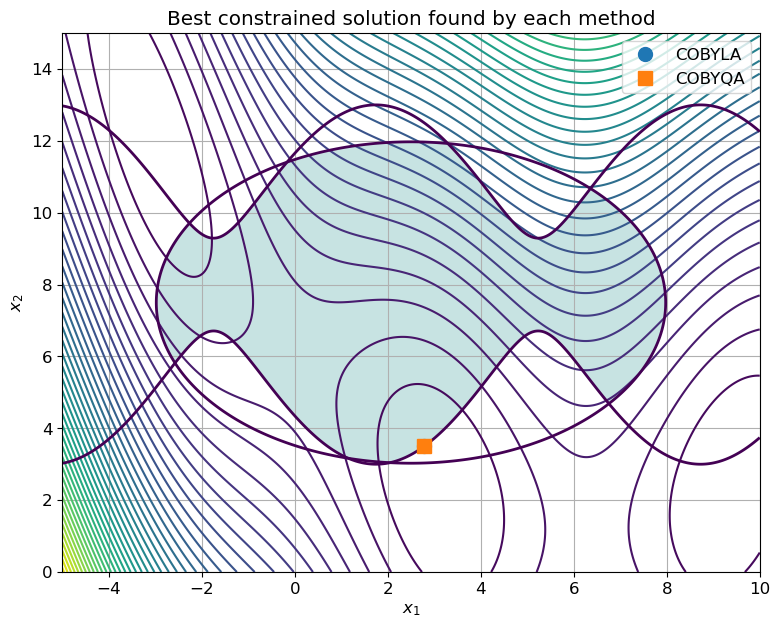

In [30]:

# Plot the best point found by each method
plt.figure(figsize=(9, 7))
plt.contour(X1, X2, F, levels=40)
plt.contour(X1, X2, C1, levels=[0], linewidths=2)
plt.contour(X1, X2, C2, levels=[0], linewidths=2)
plt.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], alpha=0.25)

markers = {"COBYLA": "o", "COBYQA": "s"} 
#, "SLSQP": "^"}

for row in summary:
    plt.plot(row["x1"], row["x2"], markers[row["method"]], markersize=10, label=row["method"])

plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Best constrained solution found by each method")
plt.legend()
plt.show()



## 6. A coarse grid-based check

For intuition, we can also scan a dense grid and find the best feasible grid point.  
This is **not** an optimization method to use in practice, but it is a nice sanity check for a 2D illustration.


In [31]:

best_val = np.inf
best_x = None

for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x = np.array([X1[i, j], X2[i, j]])
        if c1(x) >= 0 and c2(x) >= 0:
            val = branin(x)
            if val < best_val:
                best_val = val
                best_x = x.copy()

print("Best feasible grid point (coarse check):")
print("x =", best_x)
print("f(x) =", best_val)
print("c1(x) =", c1(best_x))
print("c2(x) =", c2(best_x))


Best feasible grid point (coarse check):
x = [2.78557114 3.51703407]
f(x) = 1.8987557340764099
c1(x) = 0.20408075670378822
c2(x) = 0.004583872379330889



## 7. Takeaways

This notebook illustrates a simple but useful pattern for constructing constrained test problems:

- start from a standard unconstrained benchmark,
- add smooth nonlinear inequalities,
- visualize the feasible set,
- use local constrained solvers,
- and use multistart when the objective is nonconvex.

For derivative-free optimization demos, this setup is useful because:

- the objective is familiar,
- the feasible region is easy to explain visually,
- and the constraints are genuinely nonlinear rather than trivial linear cuts.


## 8. Record and plot optimization diagnostics

The next cells show how to record the iterate sequence for each optimizer and then plot three diagnostics:

- the optimization trajectory in the $(x_1,x_2)$ plane,
- the objective history $f(\mathbf{x}_k)$,
- the maximum constraint violation history
  \\[
  v(\mathbf{x}_k)=\max\{0,-c_1(\mathbf{x}_k),-c_2(\mathbf{x}_k)\}.
  \\]

The code below is written so you can drop it into the notebook directly.


In [32]:

# --- Diagnostics helpers ---

def max_constraint_violation(x):
    return max(0.0, -c1(x), -c2(x))


def make_recorder(history):
    """Return a SciPy callback that stores iterates in `history`."""
    def callback(*args, **kwargs):
        xk = None

        # Some methods may pass an OptimizeResult via keyword.
        if "intermediate_result" in kwargs:
            ir = kwargs["intermediate_result"]
            if hasattr(ir, "x"):
                xk = np.asarray(ir.x, dtype=float).copy()

        # Many methods pass xk as the first positional argument.
        if xk is None and len(args) >= 1:
            candidate = args[0]
            if hasattr(candidate, "x"):
                xk = np.asarray(candidate.x, dtype=float).copy()
            else:
                xk = np.asarray(candidate, dtype=float).copy()

        if xk is not None:
            history.append(xk)

    return callback


def run_with_history(method, x0, bounds=None, constraints=(), options=None):
    history = [np.asarray(x0, dtype=float).copy()]

    result = minimize(
        branin,
        x0=np.asarray(x0, dtype=float),
        method=method,
        bounds=bounds,
        constraints=constraints,
        callback=make_recorder(history),
        options={} if options is None else options,
    )

    # Append the final point if the callback did not already store it.
    x_final = np.asarray(result.x, dtype=float)
    if np.linalg.norm(history[-1] - x_final) > 1e-12:
        history.append(x_final.copy())

    hist = np.asarray(history)
    f_hist = np.array([branin(x) for x in hist])
    v_hist = np.array([max_constraint_violation(x) for x in hist])

    return result, hist, f_hist, v_hist



In [33]:

# --- Run each method from the same starting point and record histories ---

x0_hist = np.array([8., 2.0])
methods = ["COBYLA", "COBYQA"]#, "SLSQP"]

history_data = {}

for method in methods:
    method_bounds = bounds if method in ["COBYQA", "SLSQP"] else None
    options = {"maxiter": 500}

    result, x_hist, f_hist, v_hist = run_with_history(
        method=method,
        x0=x0_hist,
        bounds=method_bounds,
        constraints=constraints,
        options=options,
    )

    history_data[method] = {
        "result": result,
        "x_hist": x_hist,
        "f_hist": f_hist,
        "v_hist": v_hist,
    }

for method in methods:
    result = history_data[method]["result"]
    print(f"{method:>6s} | success={result.success!s:5s} | nit={getattr(result, 'nit', 'NA')} | f={result.fun:.6f} | x={result.x}")



COBYLA | success=True  | nit=NA | f=31.088293 | x=[6.75633229 4.68531998]
COBYQA | success=True  | nit=45 | f=31.088293 | x=[6.75633229 4.68531998]


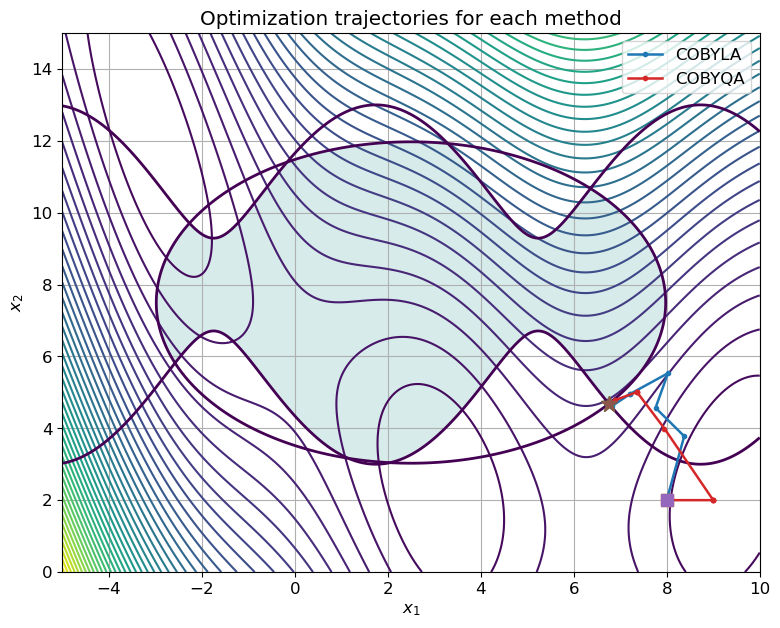

In [34]:

# --- Plot optimization trajectories in the design space ---

plt.figure(figsize=(9, 7))
plt.contour(X1, X2, F, levels=40)
plt.contour(X1, X2, C1, levels=[0], linewidths=2)
plt.contour(X1, X2, C2, levels=[0], linewidths=2)
plt.contourf(X1, X2, feasible.astype(float), levels=[0.5, 1.5], alpha=0.18)

for method in methods:
    x_hist = history_data[method]["x_hist"]
    plt.plot(x_hist[:, 0], x_hist[:, 1], marker='o', ms=3, lw=1.8, label=method)
    plt.plot(x_hist[0, 0], x_hist[0, 1], marker='s', ms=8)
    plt.plot(x_hist[-1, 0], x_hist[-1, 1], marker='*', ms=12)

plt.xlim(bounds[0])
plt.ylim(bounds[1])
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Optimization trajectories for each method")
plt.legend()
plt.show()



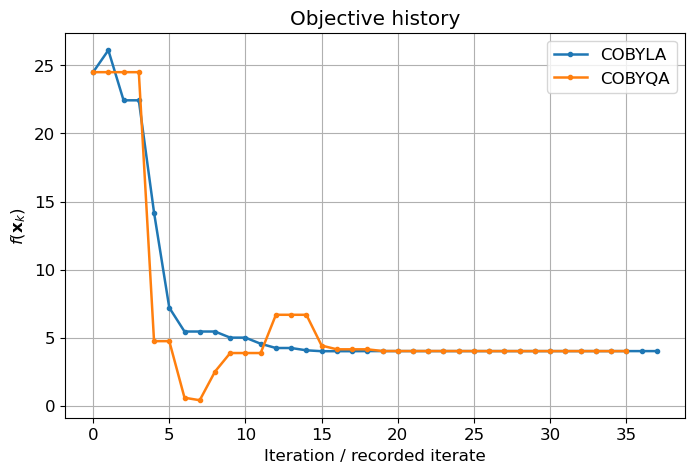

In [18]:

# --- Plot objective histories ---

plt.figure(figsize=(8, 5))
for method in methods:
    f_hist = history_data[method]["f_hist"]
    plt.plot(np.arange(len(f_hist)), f_hist, marker='o', ms=3, lw=1.8, label=method)

plt.xlabel("Iteration / recorded iterate")
plt.ylabel(r"$f(\mathbf{x}_k)$")
plt.title("Objective history")
plt.legend()
plt.show()



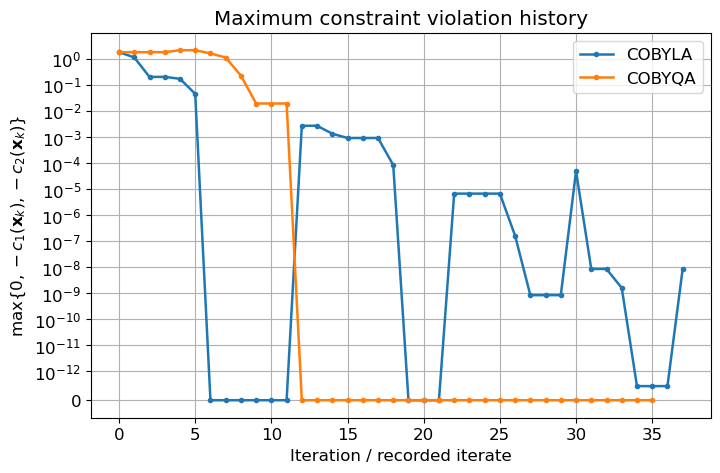

In [19]:

# --- Plot maximum constraint violation histories ---

plt.figure(figsize=(8, 5))
for method in methods:
    v_hist = history_data[method]["v_hist"]
    plt.plot(np.arange(len(v_hist)), v_hist, marker='o', ms=3, lw=1.8, label=method)

plt.xlabel("Iteration / recorded iterate")
plt.ylabel(r"$\max\{0,-c_1(\mathbf{x}_k),-c_2(\mathbf{x}_k)\}$")
plt.title("Maximum constraint violation history")
plt.yscale("symlog", linthresh=1e-12)
plt.legend()
plt.show()

